# Human in the Loop Middleware

> **Key idea:** Human-in-the-loop (HITL) middleware pauses an agent before sensitive actions so a person can approve, reject, or modify the proposed action.

## Why use human approval?

Language models can make incorrect decisions or request tools with unsafe consequences. HITL adds a human decision point for actions such as:

- sending emails or messages
- deleting or updating records
- making purchases or financial changes
- publishing content
- accessing sensitive information
- executing irreversible operations

The agent can continue automatically for low-risk tasks and request approval only for high-risk actions.

## How the HITL flow works

1. The user sends a request.
2. The model decides that a tool should be called.
3. HITL middleware interrupts execution before the sensitive tool call.
4. The proposed tool name and arguments are shown to a human.
5. The human approves, rejects, or edits the request.
6. The agent resumes from the saved state.
7. The tool runs only if the human decision allows it.

```text
User request
    |
    v
Model proposes a tool call
    |
    v
HITL interrupt
    |
    +--> Approve --> Tool executes --> Final response
    |
    +--> Reject  --> Agent explains that the action was declined
    |
    +--> Edit    --> Updated request is reviewed or executed
```

## `HumanInTheLoopMiddleware`

LangChain provides `HumanInTheLoopMiddleware` for interrupting selected tool calls:

```python
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[send_email, get_weather],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": True,
                "get_weather": False,
            }
        )
    ],
    checkpointer=InMemorySaver(),
)
```

In this example, email sending requires approval, while reading weather information can run automatically.

## Checkpointing and thread IDs

The agent needs a checkpointer to save its state when execution pauses. A `thread_id` identifies the conversation so it can be resumed later:

```python
config = {
    "configurable": {
        "thread_id": "user-123"
    }
}
```

Without a checkpointer and stable thread ID, the agent cannot reliably continue from the interrupted point.

## Resume after an interrupt

The application must inspect the interrupt, collect a human decision, and resume the same thread. The exact command depends on the LangGraph/LangChain version, but the general pattern is:

```python
result = agent.invoke(request, config=config)

# After displaying the proposed action and collecting approval:
result = agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config,
)
```

Possible decisions commonly include:

- `approve`: allow the proposed action
- `reject`: block the action
- `edit`: change the tool arguments before execution

Import `Command` from the package version used by the project:

```python
from langgraph.types import Command
```

## Safety principles

- Require approval for irreversible or high-impact actions.
- Show the exact tool name and arguments before approval.
- Never hide important context from the reviewer.
- Validate edited arguments before executing the tool.
- Treat rejection as a normal workflow outcome, not as an exception.
- Keep approval decisions auditable with timestamps and user identity.
- Use least-privilege tools and avoid exposing unnecessary sensitive data.

## HITL versus middleware logging

- Logging middleware observes execution.
- HITL middleware pauses execution and waits for a decision.
- Authentication middleware checks who is allowed to act.
- Tool middleware can validate arguments or catch tool errors.

These middleware types can be combined, but their order should be chosen carefully.

## Important revision points

- HITL creates a human approval boundary inside an agent workflow.
- Interrupts happen before selected tool calls execute.
- Checkpointing preserves the paused state.
- A stable `thread_id` is required to resume the same conversation.
- Approval should be based on the actual tool arguments, not only the user's original request.
- HITL is most important for actions that are sensitive, costly, external, or irreversible.


In [87]:
from dotenv import load_dotenv
load_dotenv()

True

In [88]:
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the current weather in a given city."""
    return f"The current weather in {city} is sunny with a temperature of 25°C."

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to a given recipient."""
    return f"Email sent to {to} with subject '{subject}' and body '{body}'."

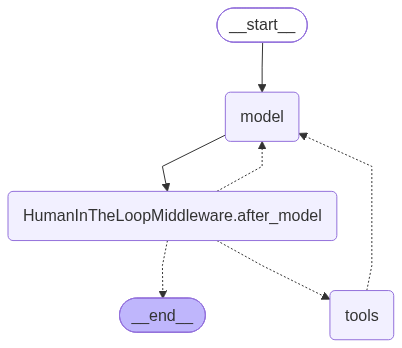

In [89]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model="groq:openai/gpt-oss-20b",
    tools=[send_email, get_weather],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": {
                    "allowed_decisions":["approve","reject","edit"],
                },
                "get_weather": False,
            }
        )
    ],
    checkpointer=InMemorySaver(),
)
agent

In [90]:
# Step 1: Request
from langchain.messages import HumanMessage
config = {
    "configurable": {
        "thread_id": "approver"
    }
}
response = agent.invoke(
    {
        "messages":[HumanMessage(content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'")],
    },
    config=config
)
for key, value in response.items():
    print("-"*100)
    print(key)
    print("-"*100)
    for i in value:
        print(i)

print("-"*100,end="\n\n")

# Step 2: Human-in-the-loop(Approve)
from langgraph.types import Command
if "__interrupt__" in response:
    print("Pause! Approving....")

    response = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"approve"}
                ]
            }
        ),
        config=config
    )

    for msg in response['messages']:
        print(msg)

----------------------------------------------------------------------------------------------------
messages
----------------------------------------------------------------------------------------------------
content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'" additional_kwargs={} response_metadata={} id='f326dba1-04a1-422d-85ba-01df09c5aff7'
content='' additional_kwargs={'reasoning_content': 'We need to call the function send_email. Provide JSON with body, subject, to.', 'tool_calls': [{'id': 'fc_e2df386d-b7b4-47ec-be58-12f4d3e1f727', 'function': {'arguments': '{"body":"Don\'t forget about the meeting tomorrow at 10 AM.","subject":"Meeting Reminder","to":"john.doe@example.com"}', 'name': 'send_email'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 193, 'total_tokens': 257, 'completion_time': 0.071813642, '

In [91]:
# Step 1: Request
from langchain.messages import HumanMessage
config = {
    "configurable": {
        "thread_id": "rejecter"
    }
}
response = agent.invoke(
    {
        "messages":[HumanMessage(content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'")],
    },
    config=config
)
for key, value in response.items():
    print("-"*100)
    print(key)
    print("-"*100)
    for i in value:
        print(i)

print("-"*100,end="\n\n")

# Step 2: Human-in-the-loop(Reject)
from langgraph.types import Command
if "__interrupt__" in response:
    print("Pause! Rejecting....")

    response = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {"type":"reject"}
                ]
            }
        ),
        config=config
    )

    for msg in response['messages']:
        print(msg)

----------------------------------------------------------------------------------------------------
messages
----------------------------------------------------------------------------------------------------
content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'" additional_kwargs={} response_metadata={} id='31b360ed-762e-4494-95aa-d6749f29c304'
content='' additional_kwargs={'reasoning_content': 'User wants to send an email. We should call the function.', 'tool_calls': [{'id': 'fc_7e6c264d-2c29-41e8-879a-5f12d83a6df4', 'function': {'arguments': '{"body":"Don\'t forget about the meeting tomorrow at 10 AM.","subject":"Meeting Reminder","to":"john.doe@example.com"}', 'name': 'send_email'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 193, 'total_tokens': 252, 'completion_time': 0.060720003, 'completion_tokens_de

In [92]:
# Step 1: Request
from langchain.messages import HumanMessage
config = {
    "configurable": {
        "thread_id": "editor"
    }
}
response = agent.invoke(
    {
        "messages":[HumanMessage(content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'")],
    },
    config=config
)
for key, value in response.items():
    print("-"*100)
    print(key)
    print("-"*100)
    for i in value:
        print(i)

print("-"*100,end="\n\n")

# Step 2: Human-in-the-loop(Edit)
from langgraph.types import Command
if "__interrupt__" in response:
    print("Pause! Editing....")

    response = agent.invoke(
        Command(
            resume={
                "decisions":[
                    {
                        "type":"edit",
                        "edited_action":{
                            "name":"send_email",
                            "args":{
                                 'to': 'edited@example.com',
                                 'subject':"edited subject",
                                 'body':'edited body'
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )

    for msg in response['messages']:
        print(msg)

----------------------------------------------------------------------------------------------------
messages
----------------------------------------------------------------------------------------------------
content="Send an email to John Doe(john.doe@example.com) about the meeting. The subject is 'Meeting Reminder' and the body is 'Don't forget about the meeting tomorrow at 10 AM.'" additional_kwargs={} response_metadata={} id='1f08a15c-7d3a-45a6-8d06-5fc313954aa2'
content='' additional_kwargs={'reasoning_content': 'User wants to send an email. Use function send_email.', 'tool_calls': [{'id': 'fc_5dc6aef3-8e0b-46d9-8833-38b82a116b99', 'function': {'arguments': '{"body":"Don\'t forget about the meeting tomorrow at 10 AM.","subject":"Meeting Reminder","to":"john.doe@example.com"}', 'name': 'send_email'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 193, 'total_tokens': 251, 'completion_time': 0.065143058, 'completion_tokens_detail